# Defensive + AND Cash Filter 최종 정리본

이 노트북은 계산이 많이 드는 실험 블록을 덜어내고, 최종적으로 남긴 두 전략만 집중해서 정리한 버전이다.

- 기준 전략: `Defensive Only`
- 개선 전략: `AND Cash Filter`
  EGARCH-X와 Markov Switching이 동시에 위험 신호를 줄 때만 현금으로 대기한다.

핵심 질문은 단순하다.
`공격/방어 스위칭`보다 `방어 유지 + 극단 위험 회피`가 실제 성과와 낙폭 관리에 더 유리한가?

### 0. 라이브러리 import 및 데이터 불러오기

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import minimize
from scipy.special import gammaln
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

PRICE_FILE = "2000_2026_코스피코스닥_수정주가_일별_비영업일제외.csv"
KOSPI200_VOLUME_FILE = "2000_2026_코스피200_일별_거래량_비영업일제외.csv"
MCAP_FILE = "2000_2026_코스피코스닥_시가총액_일별_비영업일제외.csv"
FACTOR_FILE = "2000_2026_KOSPI200, SMB, HML, MOM_수정종가_91CD_알별_비영업일제외.csv"

price = pd.read_csv(PRICE_FILE, index_col=0, parse_dates=True).sort_index()
kospi200_volume = pd.read_csv(KOSPI200_VOLUME_FILE, index_col=0, parse_dates=True).sort_index()
mcap = pd.read_csv(MCAP_FILE, index_col=0, parse_dates=True).sort_index()
factor = pd.read_csv(FACTOR_FILE, index_col=0, parse_dates=True).sort_index()

### 1. 초기 작업 및 설정

- 일별 수익률과 FF4 요인을 정리한다.
- 월말은 달력상 월말이 아니라 실제 마지막 거래일을 사용한다.
- 베타 추정은 `252거래일` 롤링, 최소 관측치는 `75%`로 둔다.

In [25]:
ret = price.pct_change(fill_method=None).iloc[1:]
logret = np.log(price / price.shift(1)).iloc[1:]


def winsorize_df(df, lower=0.005, upper=0.995):
    lower_q = df.quantile(lower)
    upper_q = df.quantile(upper)
    return df.clip(lower=lower_q, upper=upper_q, axis=1)


rf_col = "CD(91)" if "CD(91)" in factor.columns else "91CD"
factor_ret = factor[["KOSPI200", "SMB", "HML", "MOM"]].pct_change(fill_method=None).iloc[1:]
rf = ((1 + factor[rf_col].iloc[1:] / 100) ** (1 / 252)) - 1

ret = winsorize_df(ret)
logret = winsorize_df(logret)
factor_ret = winsorize_df(factor_ret)

factor_ret["RF"] = rf
factor_ret["MKT"] = factor_ret["KOSPI200"] - factor_ret["RF"]
ff4 = factor_ret[["MKT", "SMB", "HML", "MOM"]]

common_index = ret.index.intersection(ff4.index)
ret = ret.loc[common_index]
logret = logret.loc[common_index]
rf = rf.loc[common_index]
ff4 = ff4.loc[common_index]
excess_ret = ret.sub(rf, axis=0)

BETA_WINDOW = 252
MIN_OBS = int(BETA_WINDOW * 0.75)

adv60 = trading_value.rolling(60).mean()
trade_days_60 = trading_value.rolling(60).count()
rebalance_dates = pd.DatetimeIndex(price.index.to_series().groupby(price.index.to_period("M")).last())
eligible_rebalance_dates = rebalance_dates[rebalance_dates.isin(excess_ret.index)]
analysis_start_date = eligible_rebalance_dates[eligible_rebalance_dates >= excess_ret.index[BETA_WINDOW - 1]][0]
rebalance_dates = eligible_rebalance_dates[eligible_rebalance_dates >= analysis_start_date]

monthly_price = price.loc[rebalance_dates]
monthly_adv60 = adv60.loc[rebalance_dates]
monthly_trade_days_60 = trade_days_60.loc[rebalance_dates]
monthly_mcap = mcap.loc[rebalance_dates]

### 2. 유니버스 필터링 및 FF4 롤링 베타 추정

방어 전략에 들어갈 종목은 아래 조건을 통과해야 한다.

- 주가 1,500원 이상
- 최근 60거래일 중 50거래일 이상 거래
- 거래대금 하위 20% 제외
- 시가총액 하위 10% 제외
- 상장 후 최소 베타 룩백 기간 경과

그 위에서 FF4 롤링 회귀를 돌리고, 시장 베타의 `|t-stat|` 하위 20%는 제거한다.

In [26]:
price_filter = monthly_price >= 1500
trade_days_filter = monthly_trade_days_60 >= 50
adv_rank_filter = monthly_adv60.rank(axis=1, pct=True) > 0.20
mcap_rank_filter = monthly_mcap.rank(axis=1, pct=True) > 0.10

trading_day_number = pd.Series(np.arange(len(price.index)), index=price.index)
first_valid_date = price.apply(pd.Series.first_valid_index)
first_valid_day_number = first_valid_date.map(trading_day_number)
rebalance_day_number = trading_day_number.loc[rebalance_dates]
listing_age = rebalance_day_number.to_numpy()[:, None] - first_valid_day_number.to_numpy()[None, :] + 1
monthly_listing_days = pd.DataFrame(listing_age, index=rebalance_dates, columns=price.columns)
listing_filter = monthly_listing_days >= BETA_WINDOW

basic_filter = (
    price_filter
    & trade_days_filter
    & adv_rank_filter
    & mcap_rank_filter
    & listing_filter
)


def fit_ols_numpy(y, x, min_obs=MIN_OBS):
    valid = np.isfinite(y) & np.isfinite(x).all(axis=1)
    nobs = int(valid.sum())
    if nobs < min_obs:
        return None

    X = np.column_stack([np.ones(nobs), x[valid]])
    y_valid = y[valid]
    dof = nobs - X.shape[1]
    if dof <= 0:
        return None

    xtx = X.T @ X
    xty = X.T @ y_valid
    if (not np.isfinite(xtx).all()) or (not np.isfinite(xty).all()):
        return None

    try:
        xtx_inv = np.linalg.inv(xtx)
    except np.linalg.LinAlgError:
        return None

    params = xtx_inv @ xty
    resid = y_valid - X @ params
    sigma2 = (resid @ resid) / dof
    if not np.isfinite(sigma2):
        return None
    se = np.sqrt(np.diag(xtx_inv) * sigma2)
    return params, se, nobs


beta_mkt = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_smb = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_hml = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_mom = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_se = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_t = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)

for dt in rebalance_dates:
    if dt not in excess_ret.index or dt not in ff4.index:
        continue

    end_idx = excess_ret.index.get_loc(dt)
    start_idx = end_idx - (BETA_WINDOW - 1)
    if start_idx < 0:
        continue

    candidate_mask = basic_filter.loc[dt].fillna(False)
    candidate_cols = candidate_mask.index[candidate_mask]
    if len(candidate_cols) == 0:
        continue

    window_index = excess_ret.index[start_idx:end_idx + 1]
    y_window = excess_ret.loc[window_index, candidate_cols]
    x_values = ff4.loc[window_index].to_numpy(dtype=float)

    for col in candidate_cols:
        result = fit_ols_numpy(y_window[col].to_numpy(dtype=float), x_values)
        if result is None:
            continue
        params, se, _ = result
        beta_mkt.loc[dt, col] = params[1]
        beta_smb.loc[dt, col] = params[2]
        beta_hml.loc[dt, col] = params[3]
        beta_mom.loc[dt, col] = params[4]
        beta_se.loc[dt, col] = se[1]
        if se[1] > 0:
            beta_t.loc[dt, col] = params[1] / se[1]

beta_t_filter = beta_t.abs().rank(axis=1, pct=True) > 0.20
final_filter = basic_filter & beta_t_filter

beta_mkt = beta_mkt.where(final_filter)
beta_smb = beta_smb.where(final_filter)
beta_hml = beta_hml.where(final_filter)
beta_mom = beta_mom.where(final_filter)
beta_se = beta_se.where(final_filter)

shr_beta_mkt = 0.6 * beta_mkt + 0.4 * 1.0
shr_beta_smb = 0.6 * beta_smb
shr_beta_hml = 0.6 * beta_hml
shr_beta_mom = 0.6 * beta_mom

### 3. Defensive Only 포트폴리오 구성

방어 점수는 다음 네 요소를 조합한다.

- 낮은 시장 베타
- 낮은 SMB 베타
- 높은 HML 베타
- 낮은 베타 표준오차

점수 상위 20%를 동일가중으로 편입한다.

In [27]:
def_rank = (
    0.3 * (-shr_beta_mkt).rank(axis=1, pct=True)
    + 0.3 * (-shr_beta_smb).rank(axis=1, pct=True)
    + 0.3 * shr_beta_hml.rank(axis=1, pct=True)
    + 0.1 * (-beta_se).rank(axis=1, pct=True)
)

def_rank = def_rank.where(final_filter)
def_selected = def_rank.rank(axis=1, pct=True) >= 0.80

def_rank.to_csv("def_rank.csv", encoding="utf-8-sig")
def_selected.astype(int).to_csv("def_selected.csv", encoding="utf-8-sig")
print("saved: def_rank.csv")
print("saved: def_selected.csv")

saved: def_rank.csv
saved: def_selected.csv


### 4. 포트폴리오 계산용 공통 함수

이 섹션에서는 백테스트, 5분위 분석, 알파 검정에 공통으로 사용할 함수들을 준비한다.

In [28]:
backtest_rebalance_dates = rebalance_dates[:-1]
next_rebalance_dates = rebalance_dates[1:]
benchmark_monthly = factor["KOSPI200"].loc[rebalance_dates].pct_change().loc[backtest_rebalance_dates].dropna()


def build_equal_weight_portfolio(selection_mask, rebalance_dates_used, ret):
    port_ret = pd.Series(index=rebalance_dates_used, dtype=float)
    port_daily_ret = pd.Series(index=ret.index, dtype=float)
    next_dates = list(rebalance_dates_used[1:]) + [rebalance_dates[-1]]

    for i, dt in enumerate(rebalance_dates_used):
        end_dt = next_dates[i]
        w = selection_mask.loc[dt].astype(float)
        w = w[w > 0]

        if len(w) == 0:
            zero_idx = ret.index[(ret.index > dt) & (ret.index <= end_dt)]
            port_daily_ret.loc[zero_idx] = 0.0
            port_ret.loc[dt] = 0.0
            continue

        w = w / w.sum()
        holding_period = ret.loc[(ret.index > dt) & (ret.index <= end_dt), w.index]
        daily_port_ret = holding_period.mul(w, axis=1).sum(axis=1)
        port_daily_ret.loc[daily_port_ret.index] = daily_port_ret
        port_ret.loc[dt] = (1 + daily_port_ret).prod() - 1

    return port_ret.dropna(), port_daily_ret.dropna()


def performance_stats(r):
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    wealth = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    n_months = len(r)
    total_return = wealth.iloc[-1] - 1
    cagr = wealth.iloc[-1] ** (12 / n_months) - 1
    ann_vol = r.std() * np.sqrt(12)
    sharpe = np.nan if ann_vol == 0 else (r.mean() * 12) / ann_vol
    hit_rate = (r > 0).mean()

    return pd.Series({
        "CAGR": cagr,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": drawdown.min(),
        "Hit Rate": hit_rate,
        "Total Return": total_return,
    })


def build_monthly_factor_data(backtest_dates, next_dates, ff4, factor, rf_col):
    rf_monthly = pd.Series(index=backtest_dates, dtype=float)
    ff4_monthly = pd.DataFrame(index=backtest_dates, columns=["MKT", "SMB", "HML", "MOM"], dtype=float)

    for i, dt in enumerate(backtest_dates):
        end_dt = next_dates[i]
        ff4_window = ff4.loc[(ff4.index > dt) & (ff4.index <= end_dt)]
        annual_rf_window = (factor.loc[(factor.index > dt) & (factor.index <= end_dt), rf_col] / 100).dropna()

        if len(ff4_window) > 0:
            ff4_monthly.loc[dt] = (1 + ff4_window).prod() - 1
        if len(annual_rf_window) > 0:
            # CD91 is quoted at an annual rate, so convert it into the monthly holding-period risk-free return.
            rf_monthly.loc[dt] = np.prod((1 + annual_rf_window) ** (1 / 252)) - 1

    return rf_monthly, ff4_monthly


def ff4_alpha_test_hac(portfolio_ret, rf_monthly, ff4_monthly, maxlags=3):
    alpha_test = pd.concat([
        portfolio_ret.rename("portfolio"),
        rf_monthly.rename("RF"),
        ff4_monthly,
    ], axis=1).dropna()

    y = alpha_test["portfolio"] - alpha_test["RF"]
    X = sm.add_constant(alpha_test[["MKT", "SMB", "HML", "MOM"]])
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

    summary = pd.Series({
        "alpha_monthly": model.params["const"],
        "alpha_annualized": (1 + model.params["const"]) ** 12 - 1,
        "alpha_tstat": model.tvalues["const"],
        "alpha_pvalue": model.pvalues["const"],
        "significant_at_5pct": model.pvalues["const"] < 0.05,
        "n_months": len(alpha_test),
        "hac_maxlags": maxlags,
    })

    coef_table = pd.DataFrame({
        "coef": model.params,
        "std_err_hac": model.bse,
        "tstat_hac": model.tvalues,
        "pvalue_hac": model.pvalues,
    })
    coef_table.index = ["alpha" if idx == "const" else idx for idx in coef_table.index]
    return summary, coef_table, model


rf_monthly, ff4_monthly = build_monthly_factor_data(backtest_rebalance_dates, next_rebalance_dates, ff4, factor, rf_col)

### 5. Defensive Only 백테스트 및 5분위 분석

`def_rank`를 기준으로 Q1~Q5를 만들고, 벤치마크와 함께 성과를 비교한다.

- Q1: 방어 점수가 가장 낮은 20%
- Q5: 방어 점수가 가장 높은 20%

,Defensive Only,Benchmark
CAGR,0.136207,0.104025
Annualized Vol,0.191987,0.215796
Sharpe,0.763322,0.566315
Max Drawdown,-0.416941,-0.469818
Hit Rate,0.591362,0.578073
Total Return,23.607173,10.968966


,Q1,Q2,Q3,Q4,Q5,Benchmark
CAGR,-0.036798,0.017161,0.082603,0.123832,0.136122,0.104025
Annualized Vol,0.310857,0.274056,0.252666,0.225489,0.191916,0.215796
Sharpe,0.037799,0.201517,0.442406,0.632590,0.763143,0.566315
Max Drawdown,-0.869039,-0.695585,-0.562859,-0.486239,-0.416576,-0.469818
Hit Rate,0.504983,0.528239,0.574751,0.594684,0.591362,0.578073
Total Return,-0.609541,0.532347,6.321635,17.696368,23.560579,10.968966


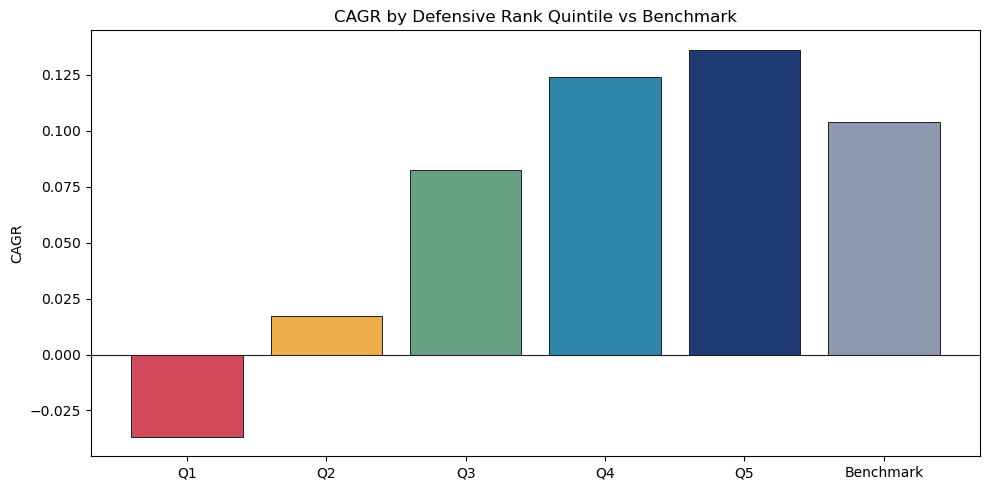

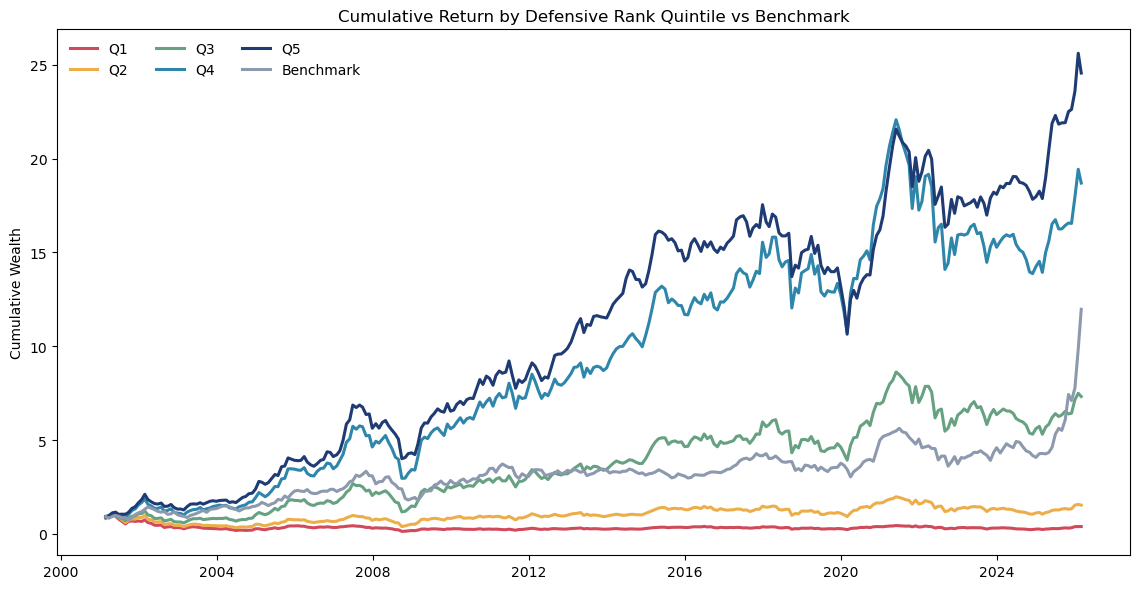

In [29]:
def_only_ret, def_only_daily = build_equal_weight_portfolio(
    def_selected.loc[backtest_rebalance_dates],
    backtest_rebalance_dates,
    ret,
)

def_result = pd.concat([
    def_only_ret.rename("Defensive Only"),
    benchmark_monthly.rename("Benchmark"),
], axis=1).dropna()

def_perf = pd.concat(
    {col: performance_stats(def_result[col]) for col in def_result.columns},
    axis=1,
)

display(def_perf)

quintile_masks = {}
rank_pct = def_rank.rank(axis=1, pct=True, method="first")
for q in range(5):
    lower = q * 0.2
    upper = (q + 1) * 0.2
    if q == 0:
        quintile_masks[f"Q{q+1}"] = rank_pct <= upper
    else:
        quintile_masks[f"Q{q+1}"] = (rank_pct > lower) & (rank_pct <= upper)

quintile_returns = {}
for name, mask in quintile_masks.items():
    q_ret, _ = build_equal_weight_portfolio(mask.loc[backtest_rebalance_dates], backtest_rebalance_dates, ret)
    quintile_returns[name] = q_ret

quintile_result = pd.concat([
    pd.DataFrame(quintile_returns),
    benchmark_monthly.rename("Benchmark"),
], axis=1).dropna()

quintile_perf = pd.concat(
    {col: performance_stats(quintile_result[col]) for col in quintile_result.columns},
    axis=1,
)

display(quintile_perf)

bar_order = ["Q1", "Q2", "Q3", "Q4", "Q5", "Benchmark"]
bar_colors = ["#d1495b", "#edae49", "#66a182", "#2e86ab", "#1f3b73", "#8d99ae"]
line_colors = dict(zip(bar_order, bar_colors))

plt.figure(figsize=(10, 5))
plt.bar(bar_order, quintile_perf.loc["CAGR", bar_order], color=bar_colors, edgecolor="#202020", linewidth=0.7)
plt.axhline(0, color="#202020", linewidth=0.8)
plt.title("CAGR by Defensive Rank Quintile vs Benchmark")
plt.ylabel("CAGR")
plt.tight_layout()
plt.show()

cum_quintile = (1 + quintile_result[bar_order]).cumprod()
plt.figure(figsize=(11.5, 6))
for col in bar_order:
    plt.plot(cum_quintile.index, cum_quintile[col], label=col, color=line_colors[col], linewidth=2.2)
plt.title("Cumulative Return by Defensive Rank Quintile vs Benchmark")
plt.ylabel("Cumulative Wealth")
plt.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

### 6. Q5-Q1 롱숏 분석

방어 점수의 정렬 능력을 더 직접적으로 보기 위해 `Q5 - Q1` 롱숏 전략도 확인한다.

- `Long`: 방어 점수가 가장 높은 Q5
- `Short`: 방어 점수가 가장 낮은 Q1

이 섹션은 점수 자체가 단순히 방어적인 종목을 고르는 것을 넘어, 상위와 하위 그룹을 실제로 분리해내는지 보는 용도다.

CAGR               0.118222
Annualized Vol     0.211968
Sharpe             0.635516
Max Drawdown      -0.409147
Hit Rate           0.578073
Total Return      15.490741
Name: Q5-Q1 Long-Short, dtype: float64

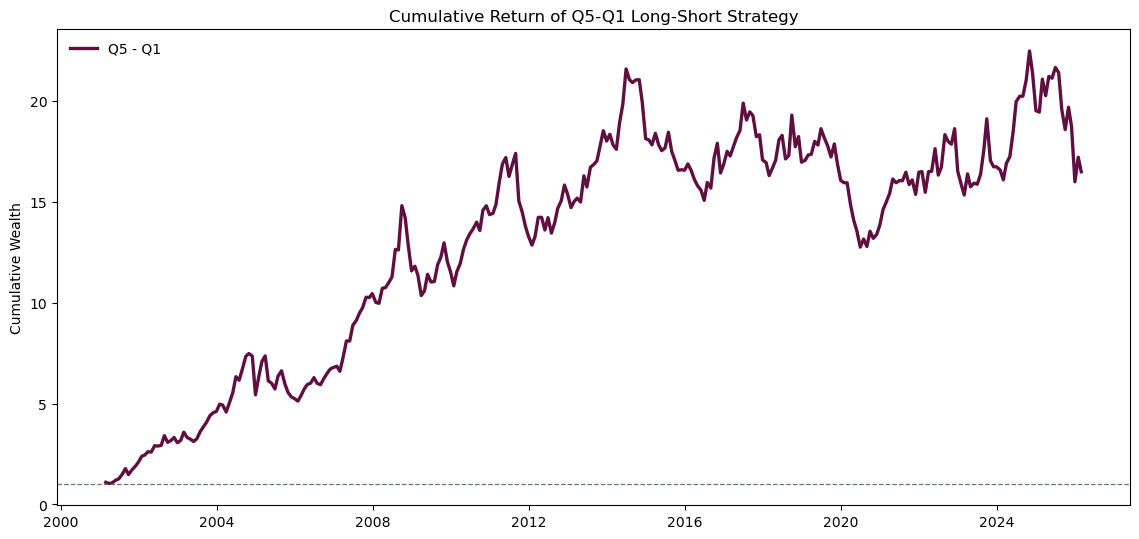

alpha_monthly         -0.000569
alpha_annualized       -0.00681
alpha_tstat           -0.301705
alpha_pvalue           0.762877
significant_at_5pct       False
n_months                    301
hac_maxlags                   3
Name: Q5-Q1 Long-Short Alpha, dtype: object

,coef,std_err_hac,tstat_hac,pvalue_hac
alpha,-0.000569,0.001887,-0.301705,7.628771e-01
MKT,-0.411320,0.048124,-8.547163,1.261507e-17
SMB,-0.699199,0.053152,-13.154788,1.597304e-39
HML,0.848726,0.051780,16.390973,2.218656e-60
MOM,0.168201,0.056680,2.967555,3.001788e-03


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     203.2
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.45e-83
Time:                        10:54:52   Log-Likelihood:                 616.50
No. Observations:                 301   AIC:                            -1223.
Df Residuals:                     296   BIC:                            -1204.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.002     -0.302      0.763      -0.004       0.003
MKT           -0.4113      0.048     -8.547      0.000      -0.506      -0.317
SMB           -0.6992      0.053    -13.155      0.000      -0.803      -0.595
HML            0.8487      0.052     16.391      0.000       0.747       0.950
MOM            0.1682      0.057      2.968      0.003       0.057       0.279
==============================================================================
Omnibus:                       12.705   Durbin-Watson:                   1.618
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               25.959
Skew:                          -0.145   Prob(JB):                     2.31e-06
Kurtosis:                       4.409   Cond. No.                         27.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

In [30]:
long_short_ret = (quintile_result["Q5"] - quintile_result["Q1"]).dropna()

long_short_perf = performance_stats(long_short_ret)
display(long_short_perf.rename("Q5-Q1 Long-Short"))

cum_long_short = (1 + long_short_ret).cumprod()
plt.figure(figsize=(11.5, 5.5))
plt.plot(cum_long_short.index, cum_long_short, color="#5f0f40", linewidth=2.4, label="Q5 - Q1")
plt.axhline(1.0, color="#6c757d", linewidth=0.9, linestyle="--")
plt.title("Cumulative Return of Q5-Q1 Long-Short Strategy")
plt.ylabel("Cumulative Wealth")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ls_rf_monthly = rf_monthly.reindex(long_short_ret.index)
ls_ff4_monthly = ff4_monthly.reindex(long_short_ret.index)
ls_alpha_summary, ls_alpha_table, ls_alpha_model = ff4_alpha_test_hac(long_short_ret, ls_rf_monthly, ls_ff4_monthly)
display(ls_alpha_summary.rename("Q5-Q1 Long-Short Alpha"))
display(ls_alpha_table)
display(ls_alpha_model.summary())


### 7. EGARCH-X + Markov Switching 현금필터

기존 스위칭 실험에서는 공격 포트폴리오 품질이 약해 성과가 저하됐다. 그래서 최종 버전에서는 `공격 전환` 대신 `극단 위험 회피`에 집중한다.

첫 번째 신호는 `EGARCH-X`이다. 이 모형은 거래량 항을 포함한 비대칭 조건부 변동성 모형으로, 다음과 같이 생각할 수 있다.

$$r_t = \varepsilon_t, \qquad \varepsilon_t = z_t\sqrt{h_t}, \qquad z_t \sim t_\nu$$

$$\log h_t = \omega + \beta \log h_{t-1} + \alpha (|z_{t-1}| - E|z|) + \gamma z_{t-1} + \theta V_{t-1}$$

여기서 $h_t$는 조건부 분산, $\gamma$는 비대칭 반응, $V_{t-1}$는 표준화한 거래량 대리변수, $\theta$는 거래량이 변동성을 얼마나 키우는지 보여주는 계수다. 즉 EGARCH-X는 가격뿐 아니라 거래량 급증이 동반된 불안정 구간까지 반영한다.

두 번째 신호는 `Markov Switching`이다. 시장수익률이 보이지 않는 두 상태(regime) 중 하나에서 나왔다고 보고, 각 시점이 고변동 상태일 확률을 추정한다.

$$r_t \mid S_t=j \sim N(\mu_j, \sigma_j^2), \qquad j \in \{0,1\}$$

$$P(S_t=j \mid S_{t-1}=i) = p_{ij}$$

우리가 실제로 쓰는 값은 고변동 상태 확률 $P(S_t=\text{high} \mid \mathcal{F}_t)$ 이다.

현금 전환 규칙은 다음과 같다.

$$\text{Cash}_t = 1\{\hat{h}^{EGARCH-X}_t \ge Q_{0.90,t}\} \times 1\{P(S_t=\text{high}) \ge 0.50\}$$

즉,

- EGARCH-X 예측변동성이 최근 36개월 분포의 상위 10% 이상이고
- 동시에 MS가 고변동 상태라고 볼 확률이 50% 이상일 때만
- 방어 포트폴리오를 비우고 현금으로 대기한다.

이 threshold를 이렇게 둔 이유는 단지 '균형이 좋아 보여서'가 아니다.

첫째, `EGARCH-X 0.90 분위`는 최근 분포의 상위 10%라는 **꼬리 위험(tail risk)** 구간만 겨냥한다. 상위 30%나 20%를 쓰면 단순한 고변동까지 많이 포함해서 현금 대기 횟수가 과도해질 수 있지만, 상위 10%는 정말 불안정한 월에 집중하는 보수적 리스크 필터에 가깝다.

둘째, `MS probability 0.50`은 **고변동 상태가 저변동 상태보다 더 가능성이 높아지는 최초 경계**다. 다시 말해 상태분류에서 다수결이 뒤집히는 베이즈 경계이므로, 0.6이나 0.7보다 해석이 자연스럽다.

셋째, 두 신호를 `AND`로 결합하면 EGARCH-X 단독의 과민한 경보와 MS 단독의 불안정한 분류를 동시에 줄일 수 있다. 따라서 이 전략은 `공격 전환 신호`가 아니라 **동시 확인된 극단 위험 경보**로 해석하는 것이 맞다.

최종 노트북에서는 아래 후보군 안에서 `Sharpe` 우선, 동률이면 `CAGR`가 더 높은 조합을 자동 선택한다.

- `EGARCH-X extreme high quantile`: `0.85`, `0.90`, `0.95`
- `MS high probability threshold`: `0.50`, `0.60`, `0.70`

따라서 섹션 8의 최종 성과표와 그래프는 이 규칙으로 다시 뽑힌 `best AND Cash Filter`를 기준으로 계산된다.

/opt/miniconda3/envs/pydata/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/pydata/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/pydata/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/pydata/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so wil

egarchx_mean_theta       0.011323
egarchx_median_theta     0.005237
egarchx_cash_months     22.000000
egarchx_q                0.850000
ms_threshold             0.700000
dtype: float64

,egarchx_q,ms_threshold,cash_months,CAGR,Annualized Vol,Sharpe,Max Drawdown,Hit Rate,Total Return
0,0.85,0.7,22,0.141498,0.175444,0.844186,-0.396081,0.559603,26.954727
1,0.90,0.7,18,0.141548,0.176411,0.840755,-0.396081,0.562914,26.985659
2,0.85,0.5,26,0.140694,0.175450,0.840098,-0.396081,0.549669,26.463458
3,0.90,0.5,21,0.141309,0.176400,0.839593,-0.396081,0.556291,26.838429
4,0.85,0.6,25,0.140242,0.175489,0.837663,-0.396081,0.549669,26.190768
5,0.90,0.6,20,0.140856,0.176439,0.837173,-0.396081,0.556291,26.562017
6,0.95,0.5,16,0.129791,0.183146,0.760075,-0.447252,0.562914,20.566669
7,0.95,0.7,14,0.129564,0.183172,0.758886,-0.447252,0.566225,20.458147
8,0.95,0.6,15,0.129343,0.183181,0.757773,-0.447252,0.562914,20.352530


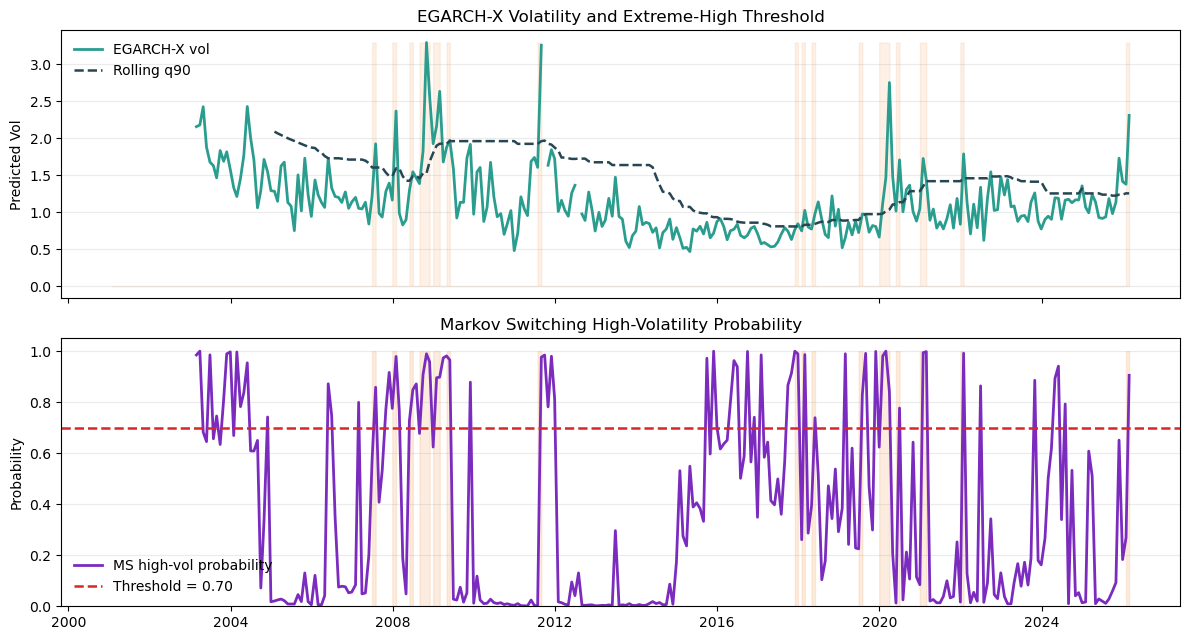

,egarchx_vol,egarchx_q90,ms_prob,cash_signal
Date,,,,
2024-03-29,0.901873,1.252326,0.618593,0
2024-04-30,1.193665,1.252326,0.893357,0
2024-05-31,1.186808,1.252326,0.941307,0
2024-06-28,0.903169,1.252326,0.339639,0
2024-07-31,1.161350,1.252326,0.792933,0
2024-08-30,1.173785,1.252326,0.010007,0
2024-09-30,1.126427,1.252326,0.532879,0
2024-10-31,1.165687,1.252326,0.040984,0
2024-11-29,1.164151,1.252326,0.053402,0


In [31]:
market_trading_value = trading_value.sum(axis=1, min_count=1).reindex(common_index)
log_market_volume = np.log1p(market_trading_value)
volume_proxy = (
    (log_market_volume - log_market_volume.rolling(252, min_periods=126).mean())
    / log_market_volume.rolling(252, min_periods=126).std()
)
volume_proxy = volume_proxy.replace([np.inf, -np.inf], np.nan).fillna(0.0)
mkt_series = factor_ret["KOSPI200"].dropna()


def fit_egarchx_volume_qmle(ret_window, vol_window):
    y = pd.Series(ret_window).dropna()
    v = pd.Series(vol_window).reindex(y.index).fillna(0.0)
    if len(y) < 500:
        return None

    y_arr = y.to_numpy(dtype=float) * 100.0
    v_arr = v.to_numpy(dtype=float)
    v_arr = (v_arr - np.nanmean(v_arr)) / (np.nanstd(v_arr) + 1e-8)
    c = np.sqrt(2.0 / np.pi)

    def unpack(params):
        omega = params[0]
        alpha = params[1]
        gamma = params[2]
        beta = 1.0 / (1.0 + np.exp(-params[3]))
        theta = params[4]
        nu = 2.0 + np.exp(params[5])
        return omega, alpha, gamma, beta, theta, nu

    def neg_ll(params):
        omega, alpha, gamma, beta, theta, nu = unpack(params)
        logh = np.empty_like(y_arr)
        logh[0] = np.log(np.var(y_arr) + 1e-6)
        for t in range(1, len(y_arr)):
            z_prev = y_arr[t - 1] / np.sqrt(np.exp(logh[t - 1]))
            logh[t] = omega + beta * logh[t - 1] + alpha * (np.abs(z_prev) - c) + gamma * z_prev + theta * v_arr[t - 1]
        h = np.exp(np.clip(logh, -20, 20))
        ll = (
            gammaln((nu + 1.0) / 2.0)
            - gammaln(nu / 2.0)
            - 0.5 * np.log((nu - 2.0) * np.pi)
            - 0.5 * np.log(h)
            - ((nu + 1.0) / 2.0) * np.log(1.0 + (y_arr ** 2) / ((nu - 2.0) * h))
        )
        if not np.isfinite(ll).all():
            return 1e12
        return -ll.sum()

    res = minimize(neg_ll, x0=np.array([0.0, 0.10, -0.05, 2.0, 0.05, np.log(8.0)]), method='L-BFGS-B')
    if (not res.success) or (not np.isfinite(res.fun)):
        return None

    omega, alpha, gamma, beta, theta, nu = unpack(res.x)
    logh = np.empty_like(y_arr)
    logh[0] = np.log(np.var(y_arr) + 1e-6)
    for t in range(1, len(y_arr)):
        z_prev = y_arr[t - 1] / np.sqrt(np.exp(logh[t - 1]))
        logh[t] = omega + beta * logh[t - 1] + alpha * (np.abs(z_prev) - c) + gamma * z_prev + theta * v_arr[t - 1]

    sigma_t = np.sqrt(np.exp(np.clip(logh[-1], -20, 20)))
    return {"sigma_t": sigma_t, "theta": theta, "nu": nu}


egarchx_vol = pd.Series(index=rebalance_dates, dtype=float)
egarchx_theta = pd.Series(index=rebalance_dates, dtype=float)
ms_high_vol_prob = pd.Series(index=rebalance_dates, dtype=float)

for dt in rebalance_dates:
    if dt in mkt_series.index and dt in volume_proxy.index:
        end_idx = mkt_series.index.get_loc(dt)
        start_idx = end_idx - 755
        if start_idx >= 0:
            window_index = mkt_series.index[start_idx:end_idx + 1]
            egx = fit_egarchx_volume_qmle(mkt_series.loc[window_index], volume_proxy.loc[window_index])
            if egx is not None:
                egarchx_vol.loc[dt] = egx["sigma_t"]
                egarchx_theta.loc[dt] = egx["theta"]

    if dt in mkt_series.index:
        end_idx = mkt_series.index.get_loc(dt)
        start_idx = end_idx - 755
        if start_idx >= 0:
            window = (mkt_series.iloc[start_idx:end_idx + 1] * 100).dropna()
            if len(window) >= 500:
                try:
                    model = MarkovRegression(window, k_regimes=2, trend="c", switching_variance=True)
                    res = model.fit(disp=False)
                    regime_vars = [res.params.get(f"sigma2[{k}]", np.nan) for k in range(2)]
                    high_regime = int(np.nanargmax(regime_vars))
                    ms_high_vol_prob.loc[dt] = res.smoothed_marginal_probabilities[high_regime].iloc[-1]
                except Exception:
                    pass

EGARCHX_Q_GRID = [0.85, 0.90, 0.95]
MS_PROB_GRID = [0.50, 0.60, 0.70]

tuning_rows = []
for q in EGARCHX_Q_GRID:
    extreme_signal = egarchx_vol >= egarchx_vol.rolling(36, min_periods=24).quantile(q)
    for ms_thr in MS_PROB_GRID:
        ms_signal = (ms_high_vol_prob >= ms_thr).reindex(extreme_signal.index).fillna(False)
        candidate_signal = (extreme_signal & ms_signal).reindex(backtest_rebalance_dates).fillna(False)
        candidate_mask = pd.DataFrame(False, index=backtest_rebalance_dates, columns=ret.columns)
        for dt in backtest_rebalance_dates:
            if not bool(candidate_signal.loc[dt]):
                candidate_mask.loc[dt] = def_selected.loc[dt]
        candidate_ret, _ = build_equal_weight_portfolio(candidate_mask, backtest_rebalance_dates, ret)
        candidate_perf = performance_stats(candidate_ret)
        tuning_rows.append({
            "egarchx_q": q,
            "ms_threshold": ms_thr,
            "cash_months": int(candidate_signal.sum()),
            **candidate_perf.to_dict(),
        })

and_tuning = pd.DataFrame(tuning_rows).sort_values(["Sharpe", "CAGR"], ascending=False).reset_index(drop=True)
best_row = and_tuning.iloc[0]
FINAL_EGARCHX_Q = float(best_row["egarchx_q"])
FINAL_MS_PROB = float(best_row["ms_threshold"])

egarchx_extreme_high = egarchx_vol >= egarchx_vol.rolling(36, min_periods=24).quantile(FINAL_EGARCHX_Q)
ms_high = ms_high_vol_prob >= FINAL_MS_PROB
and_cash_signal = (egarchx_extreme_high & ms_high.reindex(egarchx_extreme_high.index).fillna(False)).reindex(backtest_rebalance_dates).fillna(False)

and_cash_mask = pd.DataFrame(False, index=backtest_rebalance_dates, columns=ret.columns)
for dt in backtest_rebalance_dates:
    if not bool(and_cash_signal.loc[dt]):
        and_cash_mask.loc[dt] = def_selected.loc[dt]

and_cash_ret, and_cash_daily = build_equal_weight_portfolio(and_cash_mask, backtest_rebalance_dates, ret)

risk_signal_summary = pd.Series({
    "egarchx_mean_theta": egarchx_theta.mean(),
    "egarchx_median_theta": egarchx_theta.median(),
    "egarchx_cash_months": int(and_cash_signal.sum()),
    "egarchx_q": FINAL_EGARCHX_Q,
    "ms_threshold": FINAL_MS_PROB,
})

display(risk_signal_summary)
display(and_tuning.head(10))

signal_view = pd.DataFrame({
    "egarchx_vol": egarchx_vol.reindex(backtest_rebalance_dates),
    "egarchx_q90": egarchx_vol.rolling(36, min_periods=24).quantile(FINAL_EGARCHX_Q).reindex(backtest_rebalance_dates),
    "ms_prob": ms_high_vol_prob.reindex(backtest_rebalance_dates),
    "cash_signal": and_cash_signal.reindex(backtest_rebalance_dates).fillna(False).astype(int),
})

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 2]})

axes[0].plot(signal_view.index, signal_view["egarchx_vol"], color="#2a9d8f", linewidth=2.0, label="EGARCH-X vol")
axes[0].plot(signal_view.index, signal_view["egarchx_q90"], color="#264653", linewidth=1.8, linestyle="--", label="Rolling q90")
axes[0].fill_between(signal_view.index, 0, signal_view["cash_signal"] * signal_view["egarchx_vol"].max(), color="#f4a261", alpha=0.15, step="pre")
axes[0].set_title("EGARCH-X Volatility and Extreme-High Threshold")
axes[0].set_ylabel("Predicted Vol")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(signal_view.index, signal_view["ms_prob"], color="#7b2cbf", linewidth=2.0, label="MS high-vol probability")
axes[1].axhline(FINAL_MS_PROB, color="#d62828", linestyle="--", linewidth=1.8, label=f"Threshold = {FINAL_MS_PROB:.2f}")
axes[1].fill_between(signal_view.index, 0, signal_view["cash_signal"], color="#f4a261", alpha=0.20, step="pre")
axes[1].set_title("Markov Switching High-Volatility Probability")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1.05)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

display(signal_view.tail(24))

#### 6-1. 예측 변동성과 실제 변동성 비교

국면모형이 실제로 유용한지 보려면, 예측 신호가 다음 달 실현변동성과 얼마나 연결되는지도 확인해야 한다.

- `EGARCH-X`는 직접적인 예측 변동성 수준을 출력하므로 다음 달 실현변동성과 바로 비교할 수 있다.
- `MS`는 엄밀한 의미의 변동성 숫자가 아니라 `고변동 상태 확률`을 출력한다. 따라서 여기서는 `MS probability`와 다음 달 실현변동성의 상관관계를 함께 본다.

즉 아래 비교는

- `corr(EGARCH-X predicted vol, realized vol)`
- `corr(MS high-vol probability, realized vol)`

를 의미한다. 전체 기간과 `2021년 이후`를 따로 보는 이유는 최근 시장 구조와 변동성 체제가 과거와 다를 수 있기 때문이다.


corr(EGARCH-X pred vol, realized vol)      0.646444
corr(MS prob, realized vol)                0.332684
corr_since_2021_EGARCH-X                   0.576856
corr_since_2021_MS                         0.316227
n_months_full_sample                     275.000000
n_months_since_2021                       62.000000
dtype: float64

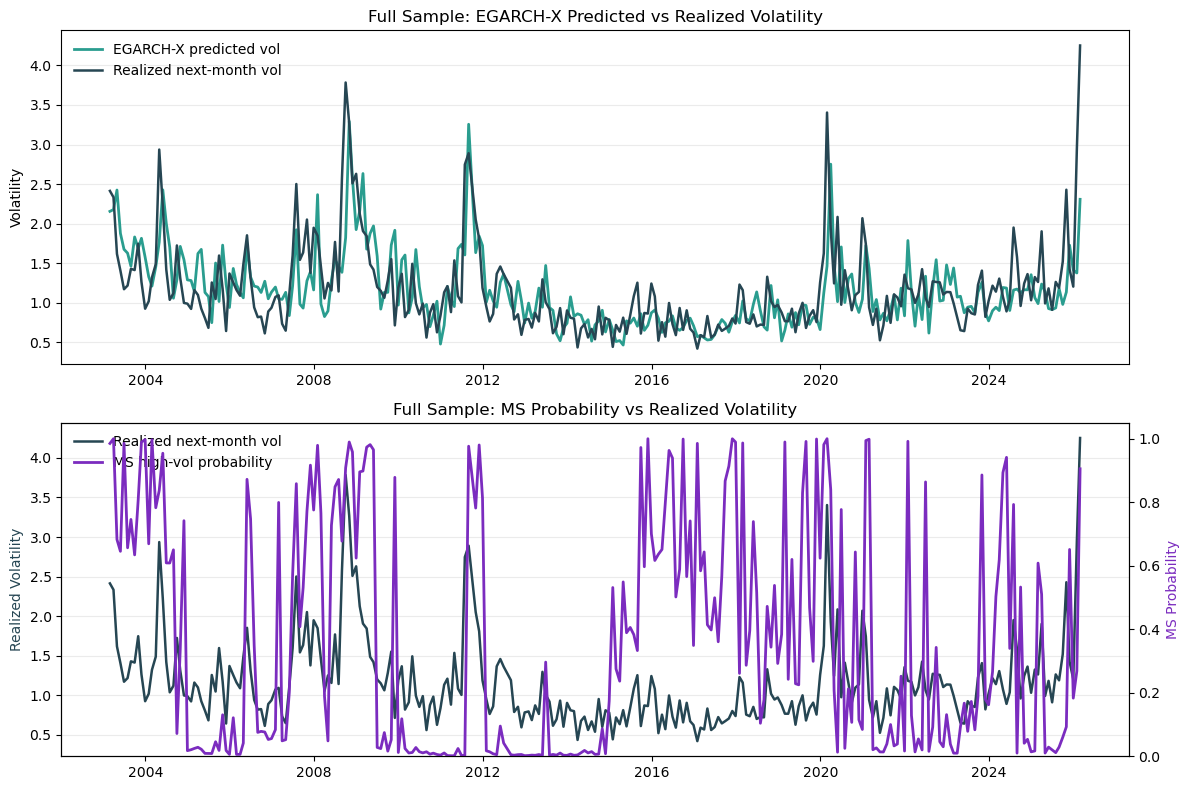

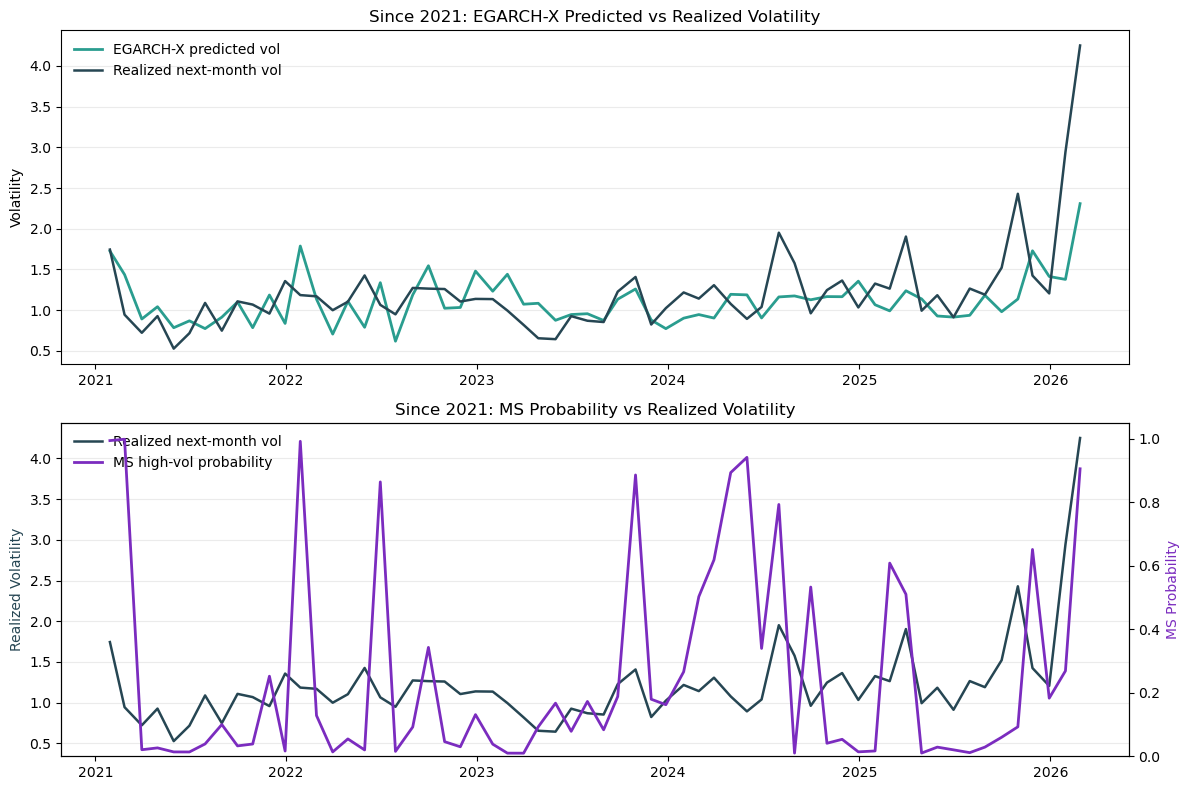

,EGARCH-X predicted vol,MS high-vol probability,Realized next-month vol
Date,,,
2024-03-29,0.901873,0.618593,1.305947
2024-04-30,1.193665,0.893357,1.075658
2024-05-31,1.186808,0.941307,0.891848
2024-06-28,0.903169,0.339639,1.037956
2024-07-31,1.161350,0.792933,1.951108
2024-08-30,1.173785,0.010007,1.576873
2024-09-30,1.126427,0.532879,0.960256
2024-10-31,1.165687,0.040984,1.245286
2024-11-29,1.164151,0.053402,1.362863


In [32]:
realized_vol = pd.Series(index=backtest_rebalance_dates, dtype=float)

for i, dt in enumerate(backtest_rebalance_dates):
    end_dt = next_rebalance_dates[i]
    window = (mkt_series.loc[(mkt_series.index > dt) & (mkt_series.index <= end_dt)] * 100).dropna()
    if len(window) > 1:
        realized_vol.loc[dt] = window.std()

vol_compare = pd.DataFrame({
    "EGARCH-X predicted vol": egarchx_vol.reindex(backtest_rebalance_dates),
    "MS high-vol probability": ms_high_vol_prob.reindex(backtest_rebalance_dates),
    "Realized next-month vol": realized_vol,
}).dropna()

recent_mask = vol_compare.index >= "2021-01-01"
vol_corr_summary = pd.Series({
    "corr(EGARCH-X pred vol, realized vol)": vol_compare["EGARCH-X predicted vol"].corr(vol_compare["Realized next-month vol"]),
    "corr(MS prob, realized vol)": vol_compare["MS high-vol probability"].corr(vol_compare["Realized next-month vol"]),
    "corr_since_2021_EGARCH-X": vol_compare.loc[recent_mask, "EGARCH-X predicted vol"].corr(vol_compare.loc[recent_mask, "Realized next-month vol"]),
    "corr_since_2021_MS": vol_compare.loc[recent_mask, "MS high-vol probability"].corr(vol_compare.loc[recent_mask, "Realized next-month vol"]),
    "n_months_full_sample": len(vol_compare),
    "n_months_since_2021": int(recent_mask.sum()),
})

display(vol_corr_summary)

full_sample = vol_compare.copy()
recent_sample = vol_compare.loc[recent_mask].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(full_sample.index, full_sample["EGARCH-X predicted vol"], color="#2a9d8f", linewidth=2.0, label="EGARCH-X predicted vol")
axes[0].plot(full_sample.index, full_sample["Realized next-month vol"], color="#264653", linewidth=1.8, label="Realized next-month vol")
axes[0].set_title("Full Sample: EGARCH-X Predicted vs Realized Volatility")
axes[0].set_ylabel("Volatility")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.25)

ax2 = axes[1].twinx()
axes[1].plot(full_sample.index, full_sample["Realized next-month vol"], color="#264653", linewidth=1.8, label="Realized next-month vol")
ax2.plot(full_sample.index, full_sample["MS high-vol probability"], color="#7b2cbf", linewidth=2.0, label="MS high-vol probability")
axes[1].set_title("Full Sample: MS Probability vs Realized Volatility")
axes[1].set_ylabel("Realized Volatility", color="#264653")
ax2.set_ylabel("MS Probability", color="#7b2cbf")
ax2.set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.25)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(recent_sample.index, recent_sample["EGARCH-X predicted vol"], color="#2a9d8f", linewidth=2.0, label="EGARCH-X predicted vol")
axes[0].plot(recent_sample.index, recent_sample["Realized next-month vol"], color="#264653", linewidth=1.8, label="Realized next-month vol")
axes[0].set_title("Since 2021: EGARCH-X Predicted vs Realized Volatility")
axes[0].set_ylabel("Volatility")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.25)

ax2 = axes[1].twinx()
axes[1].plot(recent_sample.index, recent_sample["Realized next-month vol"], color="#264653", linewidth=1.8, label="Realized next-month vol")
ax2.plot(recent_sample.index, recent_sample["MS high-vol probability"], color="#7b2cbf", linewidth=2.0, label="MS high-vol probability")
axes[1].set_title("Since 2021: MS Probability vs Realized Volatility")
axes[1].set_ylabel("Realized Volatility", color="#264653")
ax2.set_ylabel("MS Probability", color="#7b2cbf")
ax2.set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.25)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

display(vol_compare.tail(24))


### 8. 최종 전략 비교

여기서는 `Defensive Only`, `AND Cash Filter`, `Benchmark`를 직접 비교한다.

,Defensive Only,AND Cash Filter,Benchmark
CAGR,0.136207,0.140371,0.104025
Annualized Vol,0.191987,0.175669,0.215796
Sharpe,0.763322,0.837629,0.566315
Max Drawdown,-0.416941,-0.396081,-0.469818
Hit Rate,0.591362,0.558140,0.578073
Total Return,23.607173,25.971494,10.968966


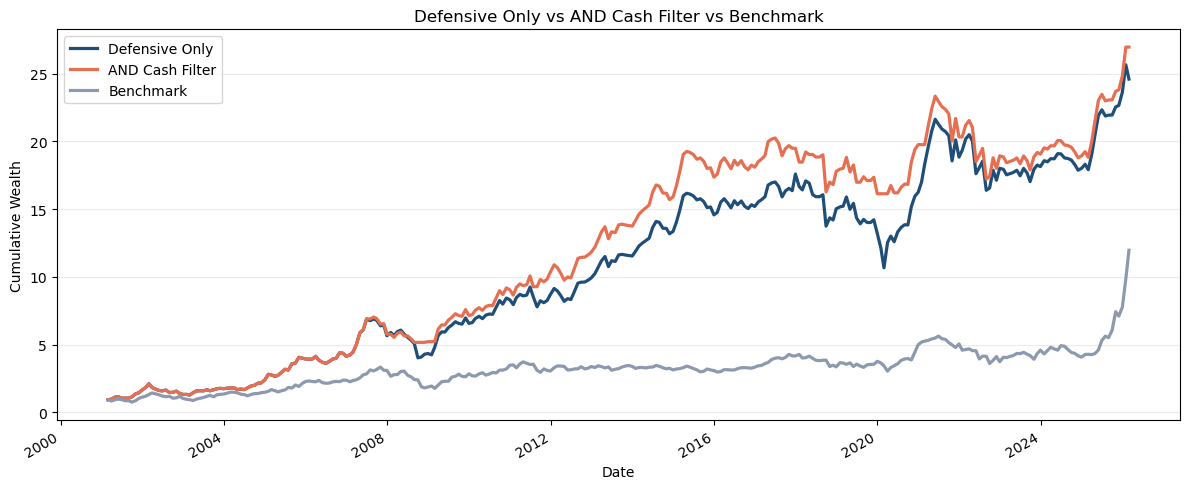

In [33]:
final_compare = pd.concat([
    def_only_ret.rename("Defensive Only"),
    and_cash_ret.rename("AND Cash Filter"),
    benchmark_monthly.rename("Benchmark"),
], axis=1).dropna()

final_compare_perf = pd.concat(
    {col: performance_stats(final_compare[col]) for col in final_compare.columns},
    axis=1,
)

display(final_compare_perf)

compare_colors = {
    "Defensive Only": "#1f4e79",
    "AND Cash Filter": "#e76f51",
    "Benchmark": "#8d99ae",
}

ax = (1 + final_compare).cumprod().plot(
    figsize=(12, 5),
    color=[compare_colors[col] for col in final_compare.columns],
    linewidth=2.3,
    title="Defensive Only vs AND Cash Filter vs Benchmark",
)
ax.set_ylabel("Cumulative Wealth")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

#### 8-1. Defensive Only vs AND Cash Filter 스프레드

`AND Cash Filter - Defensive Only` 스프레드는 현금필터가 방어 전략 대비 월별로 얼마나 추가가치를 만들었는지 보여준다.

- 양(+) 수익률: 그 달엔 현금필터가 더 유리했음
- 음(-) 수익률: 그 달엔 순수 방어 전략이 더 유리했음


CAGR             -0.002376
Annualized Vol    0.077361
Sharpe            0.007726
Max Drawdown     -0.334836
Hit Rate          0.039867
Total Return     -0.057912
Name: AND Cash Filter - Defensive Only, dtype: float64

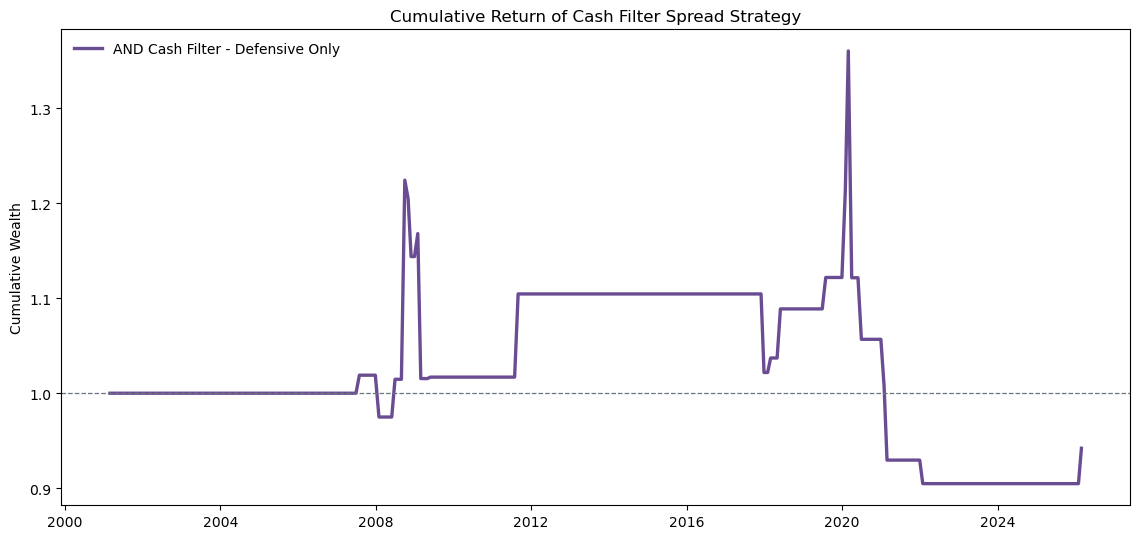

alpha_monthly         -0.001268
alpha_annualized      -0.015105
alpha_tstat           -1.064005
alpha_pvalue           0.287326
significant_at_5pct       False
n_months                    301
hac_maxlags                   3
Name: Cash Filter Spread Alpha, dtype: object

,coef,std_err_hac,tstat_hac,pvalue_hac
alpha,-0.001268,0.001191,-1.064005,0.287326
MKT,-0.130230,0.050954,-2.555821,0.010594
SMB,-0.109195,0.047923,-2.278553,0.022694
HML,-0.085210,0.050346,-1.692487,0.090553
MOM,0.081261,0.049432,1.643888,0.100199


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     1.750
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.139
Time:                        10:58:34   Log-Likelihood:                 746.69
No. Observations:                 301   AIC:                            -1483.
Df Residuals:                     296   BIC:                            -1465.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.001     -1.064      0.287      -0.004       0.001
MKT           -0.1302      0.051     -2.556      0.011      -0.230      -0.030
SMB           -0.1092      0.048     -2.279      0.023      -0.203      -0.015
HML           -0.0852      0.050     -1.692      0.091      -0.184       0.013
MOM            0.0813      0.049      1.644      0.100      -0.016       0.178
==============================================================================
Omnibus:                      107.198   Durbin-Watson:                   2.234
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10431.004
Skew:                           0.207   Prob(JB):                         0.00
Kurtosis:                      31.836   Cond. No.                         27.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

In [34]:
cash_spread_ret = (final_compare["AND Cash Filter"] - final_compare["Defensive Only"]).dropna()

cash_spread_perf = performance_stats(cash_spread_ret)
display(cash_spread_perf.rename("AND Cash Filter - Defensive Only"))

cum_cash_spread = (1 + cash_spread_ret).cumprod()
plt.figure(figsize=(11.5, 5.5))
plt.plot(cum_cash_spread.index, cum_cash_spread, color="#6a4c93", linewidth=2.4, label="AND Cash Filter - Defensive Only")
plt.axhline(1.0, color="#6c757d", linewidth=0.9, linestyle="--")
plt.title("Cumulative Return of Cash Filter Spread Strategy")
plt.ylabel("Cumulative Wealth")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

cash_spread_rf = rf_monthly.reindex(cash_spread_ret.index)
cash_spread_ff4 = ff4_monthly.reindex(cash_spread_ret.index)
cash_spread_alpha, cash_spread_alpha_table, cash_spread_alpha_model = ff4_alpha_test_hac(cash_spread_ret, cash_spread_rf, cash_spread_ff4)
display(cash_spread_alpha.rename("Cash Filter Spread Alpha"))
display(cash_spread_alpha_table)
display(cash_spread_alpha_model.summary())


#### 8-2. Q5-Q1 롱숏 + AND Cash Filter

이번에는 `Q5 - Q1` 롱숏 스프레드 자체에 `AND Cash Filter`를 덧씌운다.

- 평소에는 `Q5 - Q1` 롱숏을 유지하고
- `AND Cash` 신호가 뜨는 달에는 롱과 숏을 모두 닫고 현금으로 대기한다.

즉 이 전략은 `정렬 신호 + risk-off overlay`가 실제로 유리한지 보는 실험이다.


,Q5-Q1 Long-Short,Q5-Q1 + AND Cash Filter
CAGR,0.118222,0.120886
Annualized Vol,0.211968,0.204544
Sharpe,0.635516,0.662952
Max Drawdown,-0.409147,-0.315057
Hit Rate,0.578073,0.544850
Total Return,15.490741,16.505077


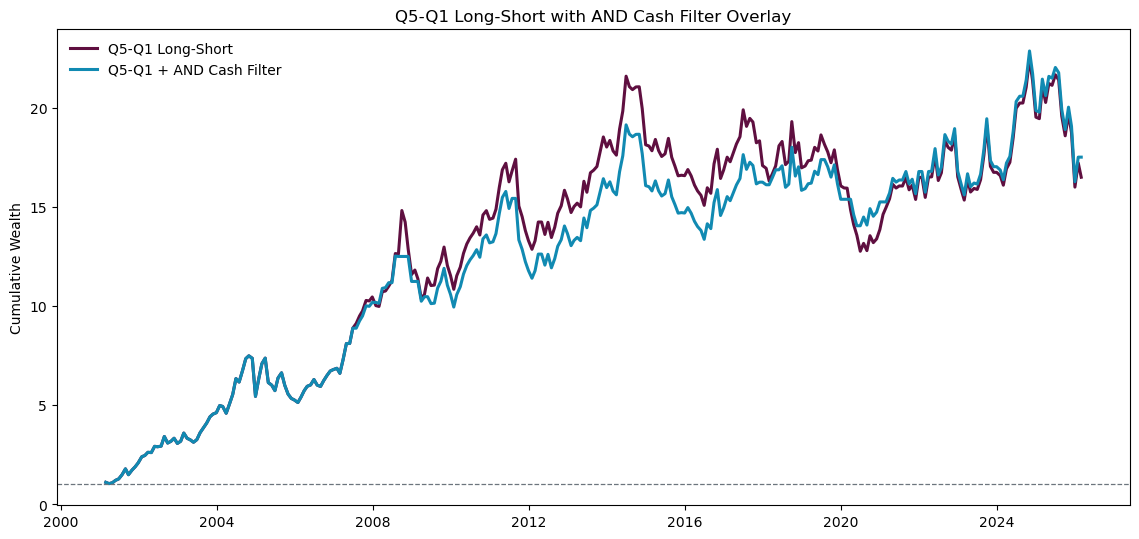

alpha_monthly         -0.000237
alpha_annualized      -0.002836
alpha_tstat           -0.118203
alpha_pvalue           0.905906
significant_at_5pct       False
n_months                    301
hac_maxlags                   3
Name: Q5-Q1 + AND Cash Filter Alpha, dtype: object

,coef,std_err_hac,tstat_hac,pvalue_hac
alpha,-0.000237,0.002002,-0.118203,9.059065e-01
MKT,-0.351058,0.058173,-6.034667,1.592909e-09
SMB,-0.631418,0.060394,-10.454969,1.390436e-25
HML,0.824683,0.057356,14.378234,7.088007e-47
MOM,0.128847,0.066427,1.939687,5.241773e-02


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     80.57
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           3.54e-46
Time:                        10:58:34   Log-Likelihood:                 595.58
No. Observations:                 301   AIC:                            -1181.
Df Residuals:                     296   BIC:                            -1163.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.002     -0.118      0.906      -0.004       0.004
MKT           -0.3511      0.058     -6.035      0.000      -0.465      -0.237
SMB           -0.6314      0.060    -10.455      0.000      -0.750      -0.513
HML            0.8247      0.057     14.378      0.000       0.712       0.937
MOM            0.1288      0.066      1.940      0.052      -0.001       0.259
==============================================================================
Omnibus:                       23.657   Durbin-Watson:                   1.714
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               56.171
Skew:                          -0.357   Prob(JB):                     6.35e-13
Kurtosis:                       4.993   Cond. No.                         27.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

In [35]:
q5_q1_cash_overlay = long_short_ret.reindex(backtest_rebalance_dates).fillna(0.0)
q5_q1_cash_overlay.loc[and_cash_signal.reindex(q5_q1_cash_overlay.index).fillna(False)] = 0.0
q5_q1_cash_overlay = q5_q1_cash_overlay.dropna()

q5_q1_overlay_compare = pd.concat([
    long_short_ret.rename("Q5-Q1 Long-Short"),
    q5_q1_cash_overlay.rename("Q5-Q1 + AND Cash Filter"),
], axis=1).dropna()

q5_q1_overlay_perf = pd.concat(
    {col: performance_stats(q5_q1_overlay_compare[col]) for col in q5_q1_overlay_compare.columns},
    axis=1,
)
display(q5_q1_overlay_perf)

plt.figure(figsize=(11.5, 5.5))
plt.plot((1 + q5_q1_overlay_compare["Q5-Q1 Long-Short"]).cumprod(), color="#5f0f40", linewidth=2.2, label="Q5-Q1 Long-Short")
plt.plot((1 + q5_q1_overlay_compare["Q5-Q1 + AND Cash Filter"]).cumprod(), color="#118ab2", linewidth=2.2, label="Q5-Q1 + AND Cash Filter")
plt.axhline(1.0, color="#6c757d", linewidth=0.9, linestyle="--")
plt.title("Q5-Q1 Long-Short with AND Cash Filter Overlay")
plt.ylabel("Cumulative Wealth")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

q5_q1_overlay_alpha, q5_q1_overlay_alpha_table, q5_q1_overlay_alpha_model = ff4_alpha_test_hac(
    q5_q1_overlay_compare["Q5-Q1 + AND Cash Filter"],
    rf_monthly.reindex(q5_q1_overlay_compare.index),
    ff4_monthly.reindex(q5_q1_overlay_compare.index),
)
display(q5_q1_overlay_alpha.rename("Q5-Q1 + AND Cash Filter Alpha"))
display(q5_q1_overlay_alpha_table)
display(q5_q1_overlay_alpha_model.summary())


### 9. 현금 전환 시점 시각화

`AND Cash Filter`가 실제로 언제 현금으로 전환되는지 본다.

- 위 패널: 누적수익률 비교
- 아래 패널: 현금 상태 여부 (`1 = Cash`, `0 = Invested`)

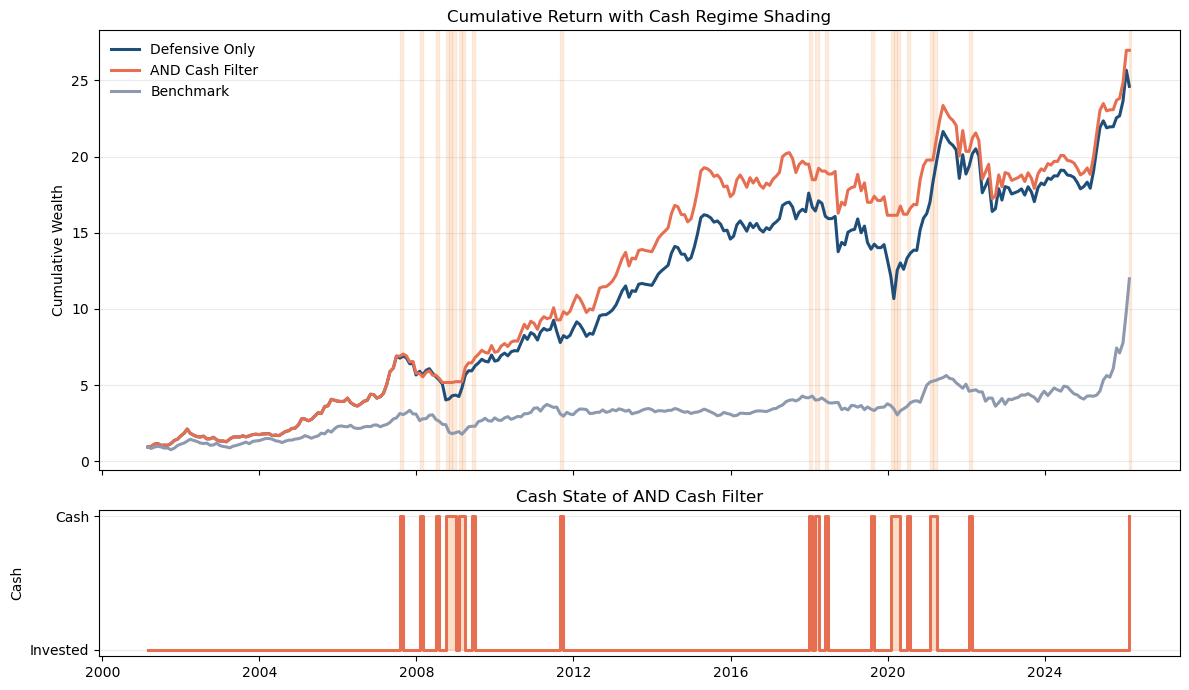

,egarchx_vol,ms_high_vol_prob,cash_signal,next_month_benchmark_ret
Date,,,,
2008-06-30,1.545042,0.848478,True,-0.044024
2008-09-30,1.823927,0.908471,True,-0.209624
2008-10-31,3.293703,0.989601,True,-0.046373
2008-11-28,2.573686,0.958257,True,0.040452
2009-01-30,2.163320,0.895652,True,-0.087623
2009-02-27,2.633776,0.898231,True,0.137177
2009-05-29,1.971344,0.965228,True,0.001623
2011-08-31,3.256440,0.976385,True,-0.048522
2017-12-28,0.842370,0.989394,True,0.026606


In [36]:
plot_compare = final_compare[["Defensive Only", "AND Cash Filter", "Benchmark"]].copy()
cum_plot = (1 + plot_compare).cumprod()

cash_state = and_cash_signal.reindex(plot_compare.index).fillna(False).astype(int)
next_dt_map = pd.Series(next_rebalance_dates, index=backtest_rebalance_dates)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

for col in cum_plot.columns:
    axes[0].plot(cum_plot.index, cum_plot[col], label=col, linewidth=2.2, color=compare_colors[col])

for dt, flag in cash_state.items():
    if flag == 1 and dt in next_dt_map.index:
        axes[0].axvspan(dt, next_dt_map.loc[dt], color="#f4a261", alpha=0.18)

axes[0].set_title("Cumulative Return with Cash Regime Shading")
axes[0].set_ylabel("Cumulative Wealth")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.25)

axes[1].step(cash_state.index, cash_state.values, where="post", color="#e76f51", linewidth=2.2)
axes[1].fill_between(cash_state.index, 0, cash_state.values, step="post", color="#f4a261", alpha=0.35)
axes[1].set_title("Cash State of AND Cash Filter")
axes[1].set_ylabel("Cash")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Invested", "Cash"])
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

cash_timing = pd.DataFrame({
    "egarchx_vol": egarchx_vol.reindex(backtest_rebalance_dates),
    "ms_high_vol_prob": ms_high_vol_prob.reindex(backtest_rebalance_dates),
    "cash_signal": and_cash_signal,
    "next_month_benchmark_ret": benchmark_monthly.shift(-1).reindex(backtest_rebalance_dates),
})

display(cash_timing[cash_timing["cash_signal"]].tail(20))

### 10. FF4 알파 검정

아래 OLS는 모두 `월수익률` 기준으로 추정한다. 따라서 무위험수익률도 `CD91 연율`을 해당 보유기간의 월율로 변환해 사용한다.
또 표준오차는 월별 자기상관 가능성을 반영하기 위해 `HAC(Newey-West, maxlags=3)`로 계산한다.

- `Defensive Only`가 FF4로 설명되지 않는 알파를 가지는지 확인한다.
- `AND Cash Filter`가 위험 회피를 통해 추가 알파를 남기는지도 같이 본다.
- 아래 각 표는 `alpha, MKT, SMB, HML, MOM` 계수의 HAC OLS 결과를 함께 보여준다.

In [37]:
def_alpha_summary, def_alpha_table, def_alpha_model = ff4_alpha_test_hac(def_only_ret, rf_monthly, ff4_monthly)
and_cash_alpha_summary, and_cash_alpha_table, and_cash_alpha_model = ff4_alpha_test_hac(and_cash_ret, rf_monthly, ff4_monthly)

alpha_compare = pd.concat([
    def_alpha_summary.rename("Defensive Only"),
    and_cash_alpha_summary.rename("AND Cash Filter"),
], axis=1)

display(alpha_compare)
display(def_alpha_table)
display(def_alpha_model.summary())
display(and_cash_alpha_table)
display(and_cash_alpha_model.summary())

,Defensive Only,AND Cash Filter
alpha_monthly,0.000622,0.001731
alpha_annualized,0.007492,0.020969
alpha_tstat,0.418169,0.913396
alpha_pvalue,0.675824,0.361034
significant_at_5pct,False,False
n_months,302,302
hac_maxlags,3,3


,coef,std_err_hac,tstat_hac,pvalue_hac
alpha,0.000622,0.001488,0.418169,6.758238e-01
MKT,0.796881,0.046986,16.959925,1.625518e-64
SMB,0.566868,0.045534,12.449457,1.408007e-35
HML,0.370883,0.049653,7.469438,8.053810e-14
MOM,0.006567,0.048781,0.134620,8.929126e-01


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     166.1
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.86e-74
Time:                        10:58:34   Log-Likelihood:                 686.05
No. Observations:                 302   AIC:                            -1362.
Df Residuals:                     297   BIC:                            -1344.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.001      0.418      0.676      -0.002       0.004
MKT            0.7969      0.047     16.960      0.000       0.705       0.889
SMB            0.5669      0.046     12.449      0.000       0.478       0.656
HML            0.3709      0.050      7.469      0.000       0.274       0.468
MOM            0.0066      0.049      0.135      0.893      -0.089       0.102
==============================================================================
Omnibus:                        9.410   Durbin-Watson:                   1.558
Prob(Omnibus):                  0.009   Jarque-Bera (JB):               17.648
Skew:                          -0.027   Prob(JB):                     0.000147
Kurtosis:                       4.183   Cond. No.                         26.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

,coef,std_err_hac,tstat_hac,pvalue_hac
alpha,0.001731,0.001895,0.913396,3.610344e-01
MKT,0.664922,0.065791,10.106614,5.163835e-24
SMB,0.454925,0.060970,7.461517,8.553179e-14
HML,0.290472,0.078464,3.701986,2.139184e-04
MOM,0.090606,0.049574,1.827692,6.759574e-02


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     38.27
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           8.01e-26
Time:                        10:58:34   Log-Likelihood:                 637.25
No. Observations:                 302   AIC:                            -1264.
Df Residuals:                     297   BIC:                            -1246.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.002      0.913      0.361      -0.002       0.005
MKT            0.6649      0.066     10.107      0.000       0.536       0.794
SMB            0.4549      0.061      7.462      0.000       0.335       0.574
HML            0.2905      0.078      3.702      0.000       0.137       0.444
MOM            0.0906      0.050      1.828      0.068      -0.007       0.188
==============================================================================
Omnibus:                       50.440   Durbin-Watson:                   1.788
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              185.529
Skew:                           0.655   Prob(JB):                     5.16e-41
Kurtosis:                       6.610   Cond. No.                         26.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

### 11. 결과 해석

이 최종 정리본은 두 가지를 보여준다.

1. `Defensive Only`는 방어 점수 자체만으로도 충분히 강한 기준 전략이다.
2. `AND Cash Filter`는 EGARCH-X와 MS가 동시에 위험을 경고하는 달에만 현금으로 대기함으로써,
   수익률을 크게 훼손하지 않으면서 변동성과 최대낙폭을 줄이는 방향으로 작동할 수 있다.

즉 이번 프로젝트의 핵심은 `공격/방어 스위칭`이 아니라
`방어 포트폴리오 유지 + 극단 위험 회피`에 있다는 점이다.

#### 알파가 낮고 유의하지 않을 때의 해석

FF4 알파가 낮고 통계적으로 유의하지 않더라도, 그 자체만으로 전략이 무의미하다고 보긴 어렵다.

첫째, 이 전략은 높은 순수 알파를 추구하는 공격 전략이 아니라 `리스크 관리형 전략`에 가깝다. 따라서 성과의 상당 부분이 시장, 가치, 규모, 모멘텀 같은 공통 요인 노출로 설명될 수 있으며, 이는 오히려 전략이 체계적으로 작동했다는 뜻일 수도 있다.

둘째, 현금필터의 목적은 새로운 초과수익을 크게 만드는 것보다 `큰 손실 구간을 피해서 샤프와 MDD를 개선하는 것`에 있다. 즉 이 전략은 알파보다 위험조정성과 downside control이 더 중요한 평가축이다.

셋째, 유의하지 않은 알파는 `FF4 바깥의 순수 초과수익은 강하지 않지만, 방어적 스타일 노출과 위험 회피 효과는 존재한다`는 해석과 더 잘 맞는다. 따라서 이 결과는 실패라기보다, 전략의 강점이 `alpha generation`보다 `drawdown control`에 있음을 보여주는 결과로 읽는 것이 자연스럽다.

### 부록. KOSPI200 + AND Cash Filter

마지막으로 동일한 `AND Cash Filter`를 방어 포트폴리오가 아니라 `KOSPI200` 자체에 적용했을 때도 의미가 있는지 확인한다.

- `KOSPI200`: 벤치마크 단순 보유
- `KOSPI200 + AND Cash Filter`: 위험 신호가 뜨는 달에는 현금 대기, 아니면 KOSPI200 보유

이 부록은 현금필터의 성과가 종목선정 효과인지, 아니면 시장 노출 관리 자체에도 기여하는지 구분하는 데 도움을 준다.


,KOSPI200,KOSPI200 + AND Cash Filter
CAGR,0.104025,0.139746
Annualized Vol,0.215796,0.195336
Sharpe,0.566315,0.768018
Max Drawdown,-0.469818,-0.391541
Hit Rate,0.578073,0.554817
Total Return,10.968966,25.603245


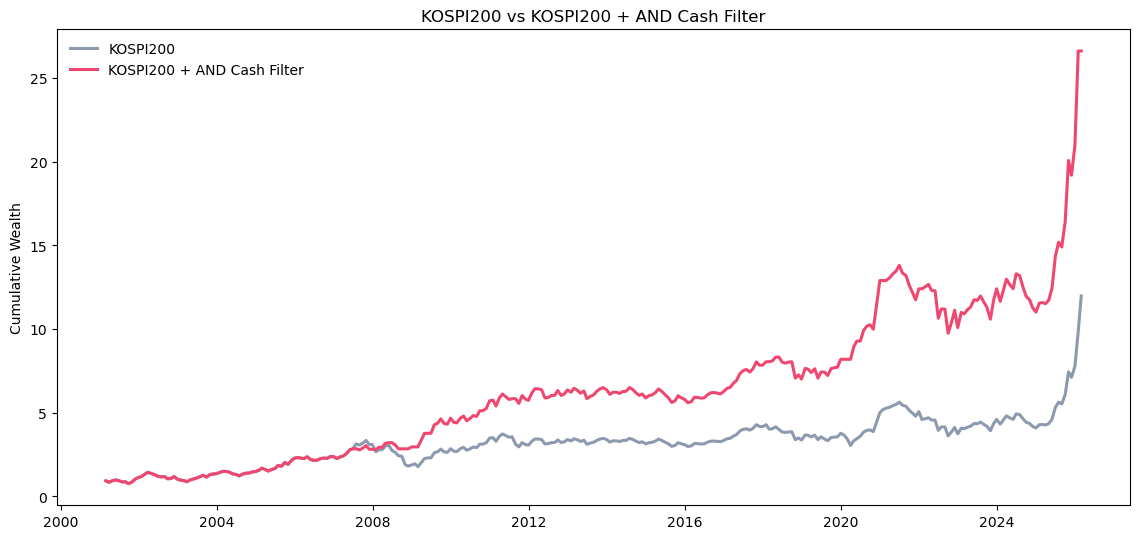

alpha_monthly          0.006761
alpha_annualized       0.084219
alpha_tstat            2.030084
alpha_pvalue           0.042348
significant_at_5pct        True
n_months                    301
hac_maxlags                   3
Name: KOSPI200 + AND Cash Filter Alpha, dtype: object

,coef,std_err_hac,tstat_hac,pvalue_hac
alpha,0.006761,0.003330,2.030084,0.042348
MKT,0.079142,0.058101,1.362140,0.173154
SMB,-0.086323,0.086139,-1.002126,0.316283
HML,0.190605,0.081175,2.348063,0.018871
MOM,0.042314,0.068141,0.620970,0.534619


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.719
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.146
Time:                        10:58:34   Log-Likelihood:                 444.26
No. Observations:                 301   AIC:                            -878.5
Df Residuals:                     296   BIC:                            -860.0
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0068      0.003      2.030      0.042       0.000       0.013
MKT            0.0791      0.058      1.362      0.173      -0.035       0.193
SMB           -0.0863      0.086     -1.002      0.316      -0.255       0.083
HML            0.1906      0.081      2.348      0.019       0.032       0.350
MOM            0.0423      0.068      0.621      0.535      -0.091       0.176
==============================================================================
Omnibus:                       18.164   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.576
Skew:                           0.413   Prob(JB):                     1.03e-06
Kurtosis:                       4.232   Cond. No.                         27.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

In [38]:
benchmark_cash_ret = benchmark_monthly.reindex(backtest_rebalance_dates).fillna(0.0)
benchmark_cash_ret.loc[and_cash_signal.reindex(benchmark_cash_ret.index).fillna(False)] = 0.0
benchmark_cash_ret = benchmark_cash_ret.dropna()

benchmark_cash_compare = pd.concat([
    benchmark_monthly.rename("KOSPI200"),
    benchmark_cash_ret.rename("KOSPI200 + AND Cash Filter"),
], axis=1).dropna()

benchmark_cash_perf = pd.concat(
    {col: performance_stats(benchmark_cash_compare[col]) for col in benchmark_cash_compare.columns},
    axis=1,
)
display(benchmark_cash_perf)

plt.figure(figsize=(11.5, 5.5))
plt.plot((1 + benchmark_cash_compare["KOSPI200"]).cumprod(), color="#8d99ae", linewidth=2.2, label="KOSPI200")
plt.plot((1 + benchmark_cash_compare["KOSPI200 + AND Cash Filter"]).cumprod(), color="#ef476f", linewidth=2.2, label="KOSPI200 + AND Cash Filter")
plt.title("KOSPI200 vs KOSPI200 + AND Cash Filter")
plt.ylabel("Cumulative Wealth")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

benchmark_cash_alpha, benchmark_cash_alpha_table, benchmark_cash_alpha_model = ff4_alpha_test_hac(
    benchmark_cash_compare["KOSPI200 + AND Cash Filter"],
    rf_monthly.reindex(benchmark_cash_compare.index),
    ff4_monthly.reindex(benchmark_cash_compare.index),
)
display(benchmark_cash_alpha.rename("KOSPI200 + AND Cash Filter Alpha"))
display(benchmark_cash_alpha_table)
display(benchmark_cash_alpha_model.summary())
